# Neural network training Tensorflow

In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use project root relative to this notebook
BASE_DIR = Path('/home/amraas/projects/realestatecons')
DATA_DIR = BASE_DIR / 'data' / 'raw'

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

In [25]:
test_df_id = test_df['Id'] # saving id for submission

In [26]:
import sys

sys.path.append(str(BASE_DIR))

from src.data.preprocess import clean_test_data, clean_train_data
from src.features.features import (
    add_engineered_features,
    add_log_transformed_features,
    drop_highly_correlated_features,
)

In [27]:
train_df_cleaned = clean_train_data(train_df)
test_df_cleaned = clean_test_data(test_df, train_df)

train_df_features = add_engineered_features(train_df_cleaned)
test_df_features = add_engineered_features(test_df_cleaned)

In [28]:
train_df = drop_highly_correlated_features(train_df_features)
test_df = drop_highly_correlated_features(test_df_features)

In [29]:
train_df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3Ss

## splitting

In [31]:
# TensorFlow setup
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import itertools


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)

# Prepare features/targets
TARGET_COL = "SalePrice"

train_df_nn = train_df.copy()
test_df_nn = test_df.copy()

y = train_df_nn[TARGET_COL].to_numpy(dtype=np.float32)
X = train_df_nn.drop(columns=[TARGET_COL])

X = pd.get_dummies(X, drop_first=True)
test_X = pd.get_dummies(test_df_nn, drop_first=True)

X, test_X = X.align(test_X, join="left", axis=1, fill_value=0)

X_np = X.to_numpy(dtype=np.float32)
test_X_np = test_X.to_numpy(dtype=np.float32)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_np,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_np).astype(np.float32)
X_val_s = scaler.transform(X_val_np).astype(np.float32)
X_test_s = scaler.transform(test_X_np).astype(np.float32)

y_train_s = y_train_np.astype(np.float32)
y_val_s = y_val_np.astype(np.float32)

I0000 00:00:1778056520.266447    9471 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778056526.316761    9471 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Grid search on train split (TensorFlow)
We tune learning rate and batch size on the train split, compare 1/2/3 hidden-layer architectures, monitor validation metrics, and save the best model outputs.

In [32]:
def regression_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    denom = tf.maximum(tf.abs(y_true), tf.constant(1.0, dtype=tf.float32))
    rel_error = tf.abs(y_true - y_pred) / denom
    return tf.reduce_mean(tf.cast(rel_error <= 0.10, tf.float32))


def build_model(input_dim: int, hidden_layers: tuple[int, ...], lr: float) -> tf.keras.Model:
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation="relu"))
    model.add(tf.keras.layers.Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[regression_accuracy, tf.keras.metrics.MeanSquaredError(name="mse")],
    )
    return model


architectures = {
    "1_hidden": (64,),
    "2_hidden": (128, 64),
    "3_hidden": (256, 128, 64),
}
learning_rates = [1e-3, 5e-4]
batch_sizes = [8, 16]
epochs = 80

results = []
best_config = None
best_model = None
best_history = None
best_rmse = np.inf

for arch_name, hidden_layers in architectures.items():
    for lr, bs in itertools.product(learning_rates, batch_sizes):
        model = build_model(X_train_s.shape[1], hidden_layers, lr)
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
        )
        history = model.fit(
            X_train_s,
            y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=bs,
            verbose=0,
            callbacks=[early_stop],
        )

        val_pred = model.predict(X_val_s, verbose=0).reshape(-1)
        val_rmse = float(np.sqrt(mean_squared_error(y_val_s, val_pred)))
        val_mae = float(mean_absolute_error(y_val_s, val_pred))
        val_r2 = float(r2_score(y_val_s, val_pred))

        results.append(
            {
                "architecture": arch_name,
                "hidden_layers": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                "val_rmse": val_rmse,
                "val_mae": val_mae,
                "val_r2": val_r2,
            }
        )

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_config = {
                "architecture": arch_name,
                "hidden_layers": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                "val_rmse": val_rmse,
                "val_mae": val_mae,
                "val_r2": val_r2,
            }
            best_model = model
            best_history = history.history

results_df = pd.DataFrame(results).sort_values("val_rmse")
results_df.head()

W0000 00:00:1778056538.737390    9471 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


,architecture,hidden_layers,learning_rate,batch_size,val_rmse,val_mae,val_r2
8,3_hidden,"(256, 128, 64)",0.0010,8,30428.255290,19970.875000,0.879291
9,3_hidden,"(256, 128, 64)",0.0010,16,31650.981659,20448.009766,0.869395
10,3_hidden,"(256, 128, 64)",0.0005,8,31859.992718,20279.521484,0.867664
11,3_hidden,"(256, 128, 64)",0.0005,16,33425.531798,22109.300781,0.854339
4,2_hidden,"(128, 64)",0.0010,8,35057.172048,22832.308594,0.839771


In [33]:
test_df_nn['Id'] = test_df_id

Best config: {'architecture': '3_hidden', 'hidden_layers': (256, 128, 64), 'learning_rate': 0.001, 'batch_size': 8, 'val_rmse': 30428.255290108238, 'val_mae': 19970.875, 'val_r2': 0.8792908191680908}


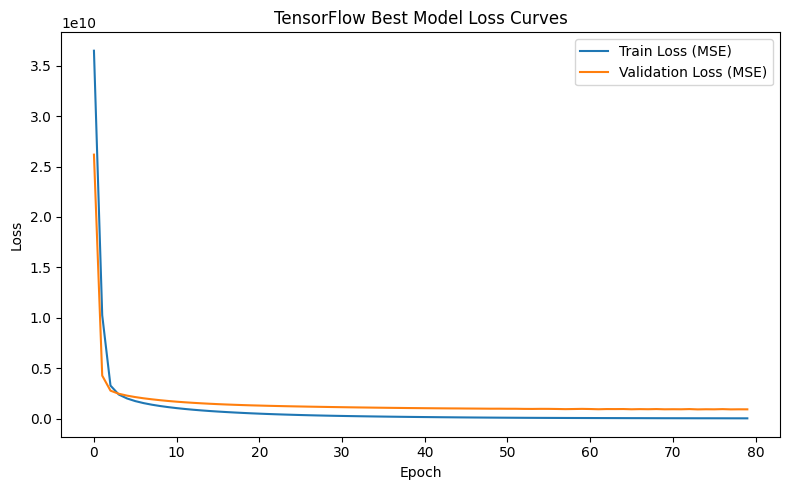

In [34]:
print("Best config:", best_config)

plt.figure(figsize=(8, 5))
plt.plot(best_history["loss"], label="Train Loss (MSE)")
plt.plot(best_history["val_loss"], label="Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Best Model Loss Curves")
plt.legend()
plt.tight_layout()
plot_dir = BASE_DIR / "reports" / "figures" / "neural_network"
plot_dir.mkdir(parents=True, exist_ok=True)
loss_curve_path = plot_dir / "tensorflow_best_loss_curve.png"
plt.savefig(loss_curve_path, dpi=150)
plt.show()

test_preds = best_model.predict(X_test_s, verbose=0).reshape(-1)


In [35]:
submission = pd.DataFrame(
    {
        "Id": test_df_nn["Id"].to_numpy(),
        "SalePrice": np.maximum(test_preds, 0),
    }
)

submission_path = BASE_DIR / "reports" / "submissions" / "neural_net_tensorflow_best.csv"
submission.to_csv(submission_path, index=False)
submission_path

PosixPath('/home/amraas/projects/realestatecons/reports/submissions/neural_net_tensorflow_best.csv')